In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\ritik\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\ritik\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
sentiment_data = pd.read_csv('fear_greed_index.csv')
historical_data = pd.read_csv('historical_data.csv')

In [3]:
sentiment_data.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
historical_data.sample(3)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
102021,0x8477e447846c758f5a675856001ea72298fd9cb5,IO,4.240000,4.7,19.93,SELL,12-06-2024 16:40,-2916.80,Open Short,0.000000,0x00000000000000000000000000000000000000000000...,25791217920,False,0.001992,4.420000e+14,1.720000e+12
68618,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,19.361000,2.0,38.72,BUY,25-02-2025 07:24,239672.74,Open Long,0.000000,0xe8dded4a1d0e29cb9438041e692aa602030800ebd1ca...,74607648914,False,0.001858,1.780000e+13,1.740000e+12
113337,0x8477e447846c758f5a675856001ea72298fd9cb5,kPEPE,0.009055,61292.0,555.00,BUY,23-04-2025 05:55,-12370820.00,Close Short,-41.433392,0x00ed8341dd216a67354b0422103e410202b300319562...,88149142649,False,0.055499,1.120000e+15,1.750000e+12


In [5]:
print("sentiment_data shape :",sentiment_data.shape)
print("historical_data shape :",historical_data.shape)

sentiment_data shape : (2644, 4)
historical_data shape : (211224, 16)


In [6]:
print("sentiment_data null values : ",sentiment_data.isnull().sum())
print("historical_data null values : ",historical_data.isnull().sum())

sentiment_data null values :  timestamp         0
value             0
classification    0
date              0
dtype: int64
historical_data null values :  Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [7]:
sentiment_data.duplicated().sum()

0

In [8]:
historical_data.duplicated().sum()

0

In [9]:
sentiment_data["Common_date"] = pd.to_datetime(sentiment_data["date"]).dt.date
historical_data["Common_date"] = pd.to_datetime(historical_data["Timestamp IST"],dayfirst=True).dt.date

In [10]:
merged_df = pd.merge(historical_data,sentiment_data,on='Common_date',how='left')

In [11]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Common_date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [12]:
merged_df.sample(10)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Common_date,timestamp,value,classification,date
153176,0x2c229d22b100a7beb69122eed721cee9b24011dd,PENGU,0.032516,25373.00,825.03,SELL,31-12-2024 20:25,37040.00000,Close Long,11.062628,...,59834722951,True,0.288759,3.490000e+14,1.740000e+12,2024-12-31,1.735623e+09,64.0,Greed,2024-12-31
203798,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,ENA,0.563400,26662.00,15021.37,BUY,03-02-2025 08:49,-162688.00000,Close Short,10564.657530,...,68816050046,False,1.502137,3.300000e+13,1.740000e+12,2025-02-03,1.738561e+09,44.0,Fear,2025-02-03
143044,0x39cef799f8b69da1995852eea189df24eb5cae3c,TRUMP,12.186000,49.80,606.86,SELL,23-03-2025 21:26,-2215.50000,Open Short,0.000000,...,81395107044,False,0.060686,2.080000e+14,1.740000e+12,2025-03-23,1.742708e+09,30.0,Fear,2025-03-23
150596,0xb899e522b5715391ae1d4f137653e7906c5e2115,BTC,83447.000000,0.63,52571.61,SELL,12-03-2025 07:13,-19.77055,Open Short,0.000000,...,79211580341,True,13.142902,3.440000e+14,1.740000e+12,2025-03-12,1.741757e+09,34.0,Fear,2025-03-12
81774,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,11.897000,6039.33,71849.91,BUY,03-04-2025 13:18,5096.27000,Open Long,0.000000,...,83595261949,True,21.554972,3.310000e+13,1.740000e+12,2025-04-03,1.743658e+09,25.0,Fear,2025-04-03
50721,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,HYPE,23.557000,77.84,1833.68,BUY,24-02-2025 01:28,-8068.64000,Close Short,90.060880,...,74304854400,True,0.641786,1.040000e+15,1.740000e+12,2025-02-24,1.740375e+09,49.0,Neutral,2025-02-24
65030,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,22.000000,288.64,6350.08,SELL,24-02-2025 18:56,63787.43000,Close Long,30.480384,...,74460808486,False,0.609607,3.880000e+14,1.740000e+12,2025-02-24,1.740375e+09,49.0,Neutral,2025-02-24
89006,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,HYPE,22.142000,19.64,434.87,BUY,02-02-2025 09:10,2222.51000,Open Long,0.000000,...,68391412348,False,0.043486,3.510000e+14,1.740000e+12,2025-02-02,1.738474e+09,60.0,Greed,2025-02-02
62289,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,23.915000,40.00,956.60,SELL,20-02-2025 01:29,13230.50000,Close Long,53.548000,...,73482924452,True,0.321417,1.830000e+14,1.740000e+12,2025-02-20,1.740029e+09,49.0,Neutral,2025-02-20
211072,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.154000,951.80,1098.38,BUY,23-04-2025 15:30,60153.70000,Open Long,0.000000,...,88264995359,False,0.109837,1.900000e+14,1.750000e+12,2025-04-23,1.745386e+09,72.0,Greed,2025-04-23


In [13]:
merged_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Common_date         0
timestamp           6
value               6
classification      6
date                6
dtype: int64

In [14]:
merged_df.duplicated().sum()

0

In [15]:
merged_df.shape

(211224, 21)

In [16]:
merged_df = merged_df.drop(columns=['date','Timestamp IST'])

In [17]:
merged_df[["Account","Common_date","classification","Closed PnL"]]

,Account,Common_date,classification,Closed PnL
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed,0.0000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed,0.0000
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed,0.0000
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed,0.0000
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed,0.0000
...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,2025-04-25,Greed,-20.2566
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,2025-04-25,Greed,-112.5773
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,2025-04-25,Greed,-22.4402
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,2025-04-25,Greed,-190.7894


In [18]:
merged_df.dropna(inplace=True)

In [19]:
merged_df["Is_Win"] = (merged_df["Closed PnL"] > 0 ).astype(int)
merged_df["Is_Long"] = (merged_df["Side"].str.upper() == 'BUY').astype(int)
merged_df["Is_Short"] = (merged_df["Side"].str.upper() == 'SELL').astype(int)

In [20]:
daily_trader_metrices = merged_df.groupby(['Common_date','Account','classification']).agg(
    Daily_PnL = ('Closed PnL','sum'),
    Total_Trades = ('Account','count'),
    Avg_Trade_Size = ('Size USD','mean'),
    Winning_Trades = ('Is_Win','sum'),
    Long_Trades = ('Is_Long','sum'),
    Short_trades = ('Is_Short','sum')
).reset_index()

In [21]:
daily_trader_metrices['Win_Rate (%)'] = (daily_trader_metrices['Winning_Trades'] / daily_trader_metrices['Total_Trades']) * 100
daily_trader_metrices['Long_Short_Ratio'] = daily_trader_metrices['Long_Trades'] / daily_trader_metrices['Short_trades'].replace(0, 1)

daily_trader_metrices.head()

,Common_date,Account,classification,Daily_PnL,Total_Trades,Avg_Trade_Size,Winning_Trades,Long_Trades,Short_trades,Win_Rate (%),Long_Short_Ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,3,159.000000,0,3,0,0.000000,3.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,0.000000,9,5556.203333,0,7,2,0.000000,3.500000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737,11,10291.213636,4,5,6,36.363636,0.833333
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034,2,5304.975000,0,2,0,0.000000,2.000000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,3,5116.256667,0,3,0,0.000000,3.000000


In [22]:
merged_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash',
       'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Common_date',
       'timestamp', 'value', 'classification', 'Is_Win', 'Is_Long',
       'Is_Short'],
      dtype='str')

In [23]:
daily_trader_metrices.columns

Index(['Common_date', 'Account', 'classification', 'Daily_PnL', 'Total_Trades',
       'Avg_Trade_Size', 'Winning_Trades', 'Long_Trades', 'Short_trades',
       'Win_Rate (%)', 'Long_Short_Ratio'],
      dtype='str')

### Part B

In [24]:
# q.1
performance_comparison = daily_trader_metrices.groupby('classification')[['Daily_PnL', 'Win_Rate (%)']].mean().reset_index()

performance_comparison = performance_comparison.rename(columns={
    'Daily_PnL': 'Average Daily PnL ($)',
    'Win_Rate (%)': 'Average Win Rate (%)'
})
print("--- Performance: Fear vs. Greed ---")
print(performance_comparison.to_string(index=False))

--- Performance: Fear vs. Greed ---
classification  Average Daily PnL ($)  Average Win Rate (%)
  Extreme Fear            4619.439053             32.965915
 Extreme Greed            5161.922644             38.638734
          Fear            5328.818161             36.403251
         Greed            3318.100730             34.355876
       Neutral            3438.618818             35.541410



Chart saved as 'performance_by_sentiment.png'


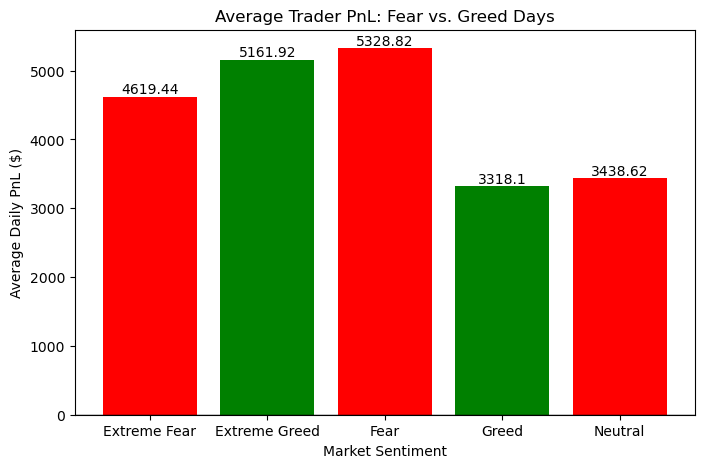

In [25]:
plt.figure(figsize=(8,5))
bars = plt.bar(performance_comparison['classification'], performance_comparison['Average Daily PnL ($)'], color=['red', 'green'])

plt.title('Average Trader PnL: Fear vs. Greed Days')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Daily PnL ($)')

plt.axhline(0, color='black' , linewidth=1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center' , va='bottom')

plt.savefig('performance_by_sentiment.png')
print("\nChart saved as 'performance_by_sentiment.png'")

In [26]:
# Part B: q.2
behavior_comparison = daily_trader_metrices.groupby('classification')[['Total_Trades', 'Avg_Trade_Size', 'Long_Short_Ratio']].mean().reset_index()
behavior_comparison = behavior_comparison.rename(columns={
    'Total_Trades': 'Avg Trades Per Day',
    'Avg_Trade_Size': 'Avg Trade Size ($)',
    'Long_Short_Ratio': 'Avg Long/Short Ratio'
})

print("--- Trader Behavior: Fear vs. Greed ---")
print(behavior_comparison.to_string(index=False))

--- Trader Behavior: Fear vs. Greed ---
classification  Avg Trades Per Day  Avg Trade Size ($)  Avg Long/Short Ratio
  Extreme Fear          133.750000         6773.464125             12.923375
 Extreme Greed           76.030418         5371.637182              5.669434
          Fear           98.153968         8975.928546              7.223640
         Greed           77.628086         6427.866594              5.774688
       Neutral          100.228723         6963.694861              6.450631



Charts saved as 'behavior_by_sentiment.png'


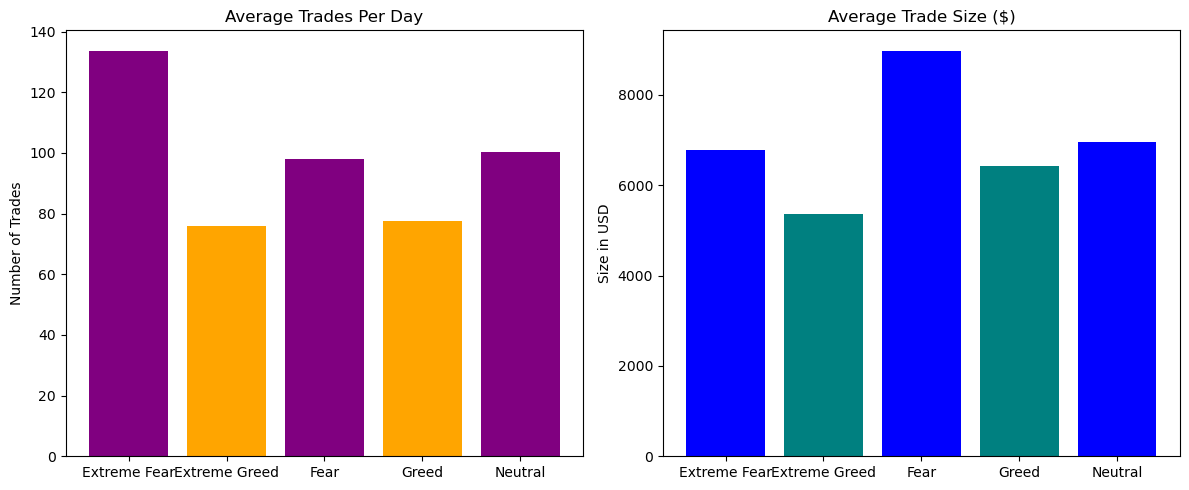

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

labels = behavior_comparison['classification']
x = np.arange(len(labels))

ax1.bar(labels, behavior_comparison['Avg Trades Per Day'], color=['purple', 'orange'])
ax1.set_title('Average Trades Per Day')
ax1.set_ylabel('Number of Trades')

ax2.bar(labels, behavior_comparison['Avg Trade Size ($)'], color=['blue', 'teal'])
ax2.set_title('Average Trade Size ($)')
ax2.set_ylabel('Size in USD')

plt.tight_layout()

plt.savefig('behavior_by_sentiment.png')
print("\nCharts saved as 'behavior_by_sentiment.png'")

In [28]:
# q.3
account_metrics = daily_trader_metrices.groupby('Account').agg(
    Total_Lifetime_Trades=('Total_Trades', 'sum'),
    Total_Lifetime_PnL=('Daily_PnL', 'sum')
).reset_index()

median_trades = account_metrics['Total_Lifetime_Trades'].median()
account_metrics['Activity_Segment'] = account_metrics['Total_Lifetime_Trades'].apply(
    lambda x: 'Frequent Trader' if x >= median_trades else 'Infrequent Trader'
)

account_metrics['Profit_Segment'] = account_metrics['Total_Lifetime_PnL'].apply(
    lambda x: 'Profitable' if x > 0 else 'Unprofitable'
)

segmented_data = pd.merge(daily_trader_metrices, account_metrics[['Account', 'Activity_Segment', 'Profit_Segment']], on='Account', how='left')

Charts successfully saved as 'segmentation_insights.png'


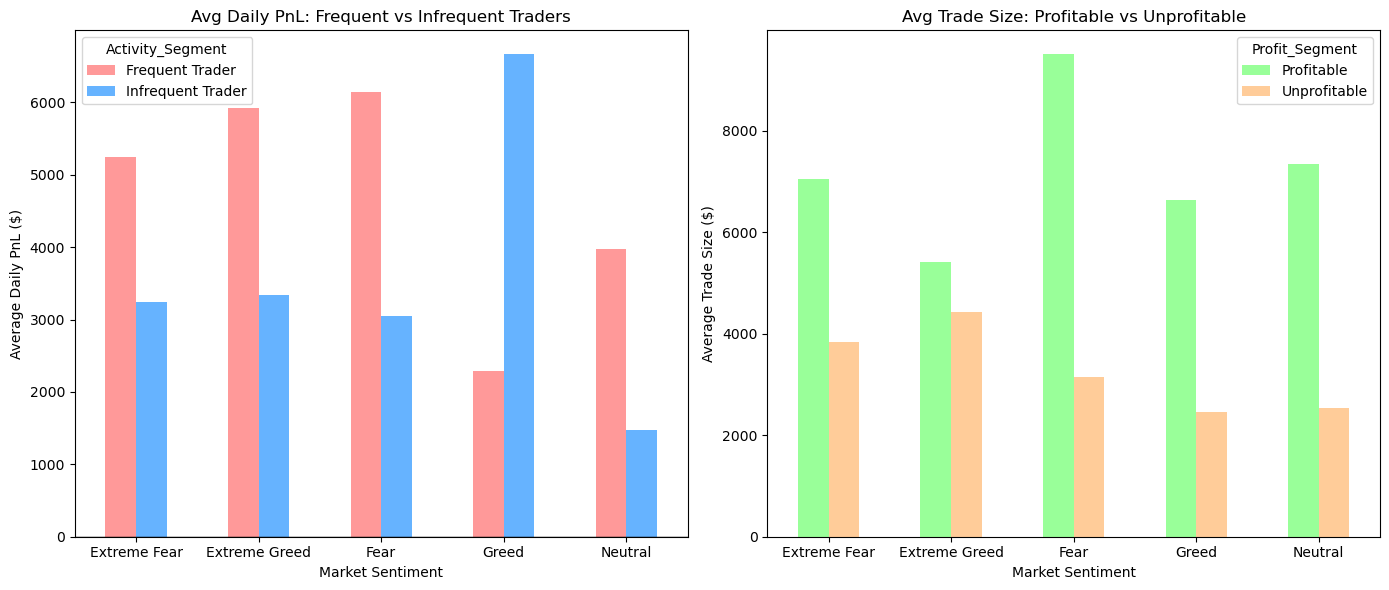

In [29]:
# q.4
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)

seg1_stats = segmented_data.groupby(['classification', 'Activity_Segment'])['Daily_PnL'].mean().unstack()
seg1_stats.plot(kind='bar', ax=plt.gca(), color=['#ff9999', '#66b3ff'])
plt.title('Avg Daily PnL: Frequent vs Infrequent Traders')
plt.ylabel('Average Daily PnL ($)')
plt.xlabel('Market Sentiment')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
seg2_stats = segmented_data.groupby(['classification', 'Profit_Segment'])['Avg_Trade_Size'].mean().unstack()
seg2_stats.plot(kind='bar', ax=plt.gca(), color=['#99ff99', '#ffcc99'])
plt.title('Avg Trade Size: Profitable vs Unprofitable')
plt.ylabel('Average Trade Size ($)')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('segmentation_insights.png')
print("Charts successfully saved as 'segmentation_insights.png'")

In [30]:
# Print the raw text data for our segments so we can build the final strategies
print("--- Segment: Frequent vs Infrequent PnL ---")
print(seg1_stats.to_string())

print("\n--- Segment: Profitable vs Unprofitable Trade Size ---")
print(seg2_stats.to_string())

--- Segment: Frequent vs Infrequent PnL ---
Activity_Segment  Frequent Trader  Infrequent Trader
classification                                      
Extreme Fear          5246.869937        3239.091109
Extreme Greed         5918.654027        3333.974107
Fear                  6139.097134        3045.304693
Greed                 2293.016352        6663.112910
Neutral               3978.072238        1473.942780

--- Segment: Profitable vs Unprofitable Trade Size ---
Profit_Segment   Profitable  Unprofitable
classification                           
Extreme Fear    7054.652047   3841.075796
Extreme Greed   5408.712108   4433.641550
Fear            9500.899350   3140.676147
Greed           6634.165652   2456.609738
Neutral         7333.317523   2540.968524


### Note: Part- C was mentioned in summary.txt

### Bonus part

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [34]:
daily_trader_metrices = daily_trader_metrices.sort_values(by=['Account', 'Common_date'])
daily_trader_metrices['Next_Day_PnL'] = daily_trader_metrices.groupby('Account')['Daily_PnL'].shift(-1)

ml_data = daily_trader_metrices.dropna(subset=['Next_Day_PnL']).copy()
ml_data['Target_Is_Profitable'] = (ml_data['Next_Day_PnL'] > 0).astype(int)

In [35]:
sentiment_mapping = {
    'Extreme Fear': 1,
    'Fear': 2,
    'Neutral': 3,
    'Greed': 4,
    'Extreme Greed': 5
}
ml_data['Sentiment_Score'] = ml_data['classification'].map(sentiment_mapping)

In [36]:
features = ['Sentiment_Score', 'Total_Trades', 'Avg_Trade_Size', 'Long_Short_Ratio']
X = ml_data[features]
y = ml_data['Target_Is_Profitable']

X = X.fillna(0)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [38]:
print("--- Predictive Model Scorecard ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Detailed Report:")
print(classification_report(y_test, y_pred))

--- Predictive Model Scorecard ---
Overall Accuracy: 67.10%

Detailed Report:
              precision    recall  f1-score   support

           0       0.63      0.30      0.41       174
           1       0.68      0.90      0.77       288

    accuracy                           0.67       462
   macro avg       0.66      0.60      0.59       462
weighted avg       0.66      0.67      0.63       462

